In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 500

In [2]:
# Datos sinteticos
MedInc = np.random.lognormal(mean=2.5, sigma= 0.35, size=n)  # Ingreso medio
HouseAge = np.random.randint(1, 52, size=n)  # Edad de la casa
Longitude = -124 + np.random.rand(n) * 10  # Longitud
Latitude = 32 + np.random.rand(n) * 10  # Latitud
AveRooms = 5 + 0.15*MedInc + 0.03*HouseAge + np.random.randn(n)

# Target
target = (
    0.45*MedInc 
    - 0.02*HouseAge
    - 0.01*(Longitude+119)
    - 0.03*(Latitude-26)
    + 0.02*AveRooms
    + np.random.randn(n)*0.5
)

df= pd.DataFrame(
    {
        'MedInc': MedInc,
        'HouseAge': HouseAge,
        'Longitude': Longitude,
        'Latitude': Latitude,
        'AveRooms': AveRooms,
        'target': target
    }
)

numeric_cols= df.columns.tolist()

In [3]:
cov_matrix= df[numeric_cols].cov()
corr_matrix= df[numeric_cols].corr()

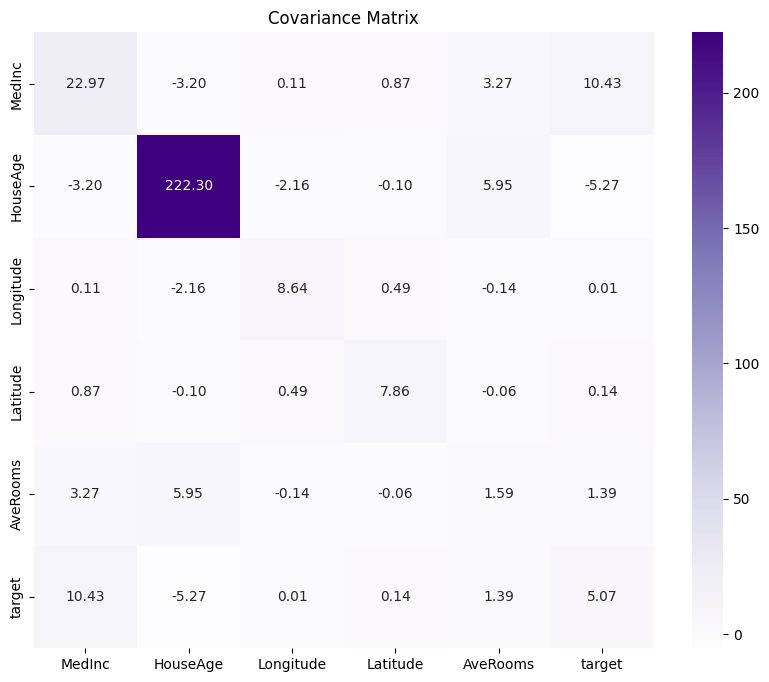

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(cov_matrix.round(3), annot=True, cmap='Purples', fmt=".2f")
plt.title('Covariance Matrix')
plt.show()

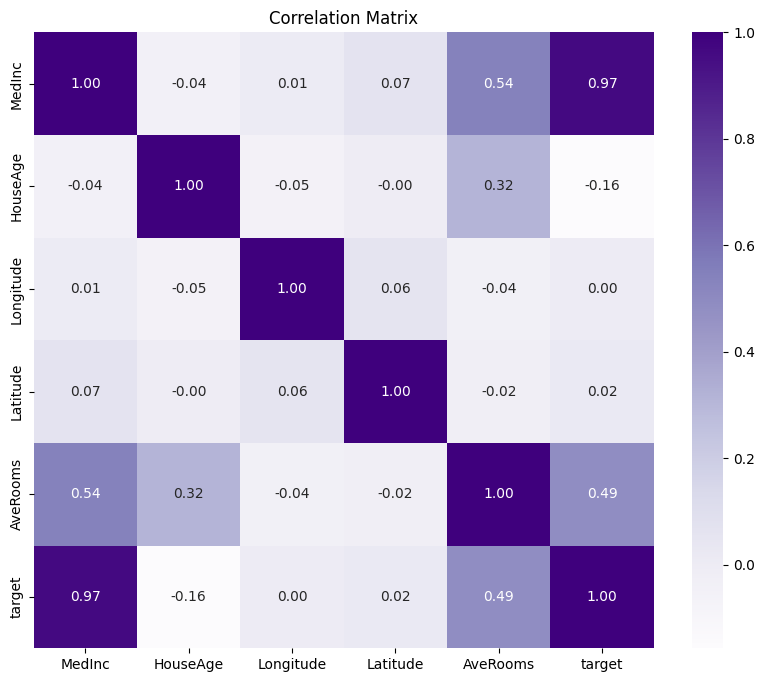

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix.round(3), annot=True, cmap='Purples', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [6]:
# Hat-Matriz
y= df['target'].values.reshape(-1,1)
X= df.drop(columns=['target']).values

In [7]:
XtX= X.T @ X
XtX_inv= np.linalg.inv(XtX)
beta= XtX_inv @ X.T @ y
# print(beta)
# print('-----------------')
y_hat= X @ beta

resid = y - y_hat

#Hat Matrix
H= X @ XtX_inv @ X.T
leverage= np.diag(H)
print(leverage)
# print('-----------------')
# print(H)

[0.00683622 0.00856576 0.01414714 0.02147145 0.00433298 0.00381917
 0.01185858 0.00394502 0.01272148 0.01973389 0.02004287 0.01157847
 0.00237357 0.0091135  0.00683445 0.00388109 0.00449014 0.00695172
 0.00870744 0.01154184 0.00943024 0.00661443 0.00670488 0.01160875
 0.01286383 0.0029964  0.01112467 0.00826874 0.00706071 0.00270629
 0.01253718 0.02046355 0.00666576 0.01510784 0.01148397 0.00639511
 0.00535846 0.01862727 0.01333234 0.00323337 0.00559464 0.00874694
 0.00495115 0.00795879 0.00859932 0.00848331 0.00725863 0.01502742
 0.00595008 0.01588016 0.00452061 0.00454365 0.00480972 0.00982702
 0.01407046 0.01982702 0.00861879 0.01301981 0.00706325 0.00907924
 0.00397255 0.00696536 0.00870402 0.00777467 0.00459963 0.01305431
 0.01114508 0.00703922 0.01094488 0.01296862 0.00687029 0.01286926
 0.00287642 0.01199086 0.01077856 0.01663146 0.00518467 0.00581662
 0.01465273 0.00696003 0.00879669 0.0119235  0.01880759 0.00516431
 0.00618522 0.00594251 0.00482889 0.00647673 0.01063726 0.0046

In [8]:
print(beta)

[[ 0.45256761]
 [-0.01738765]
 [-0.00756543]
 [-0.03212901]
 [ 0.00348242]]


In [9]:
print(H)

[[ 6.83621791e-03 -3.43146895e-03  4.92609479e-03 ... -1.64389678e-03
   4.40029373e-03  6.39441184e-03]
 [-3.43146895e-03  8.56576249e-03 -6.72220051e-05 ...  6.86701796e-03
  -9.10779318e-05 -2.53237072e-03]
 [ 4.92609479e-03 -6.72220051e-05  1.41471420e-02 ...  3.12593551e-03
   6.28860330e-03 -1.79741531e-04]
 ...
 [-1.64389678e-03  6.86701796e-03  3.12593551e-03 ...  6.38716528e-03
   2.04349450e-03 -1.09337805e-03]
 [ 4.40029373e-03 -9.10779318e-05  6.28860330e-03 ...  2.04349450e-03
   6.99383065e-03  7.15306546e-03]
 [ 6.39441184e-03 -2.53237072e-03 -1.79741531e-04 ... -1.09337805e-03
   7.15306546e-03  1.49720975e-02]]


In [10]:
print('H', H.shape)
print('X', X.shape)
print('y', y.shape)
print('beta', beta.shape)

H (500, 500)
X (500, 5)
y (500, 1)
beta (5, 1)


In [11]:
n, p = X.shape
print("n", n)
print("p", p)

avg_lev = p/n
threshold = 2*avg_lev
print("avg_lev", avg_lev)
print("threshold", threshold)

n 500
p 5
avg_lev 0.01
threshold 0.02


In [12]:
summary= pd.DataFrame({
    'index':np.arange(n),
    'leverage': leverage,
    'y': y.flatten(),
    'y_hat': y_hat.flatten(),
    'resid': resid.flatten()
})

In [13]:
print('Top Ten Leverage Points')
print(summary.sort_values(by='leverage', ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage       y   y_hat  resid
209    209     0.116  21.103  21.052  0.051
478    478     0.049  15.981  15.678  0.303
179    179     0.035  12.742  13.509 -0.766
378    378     0.029  10.609  11.264 -0.655
362    362     0.029   3.830   4.381 -0.552
416    416     0.029   7.930   8.623 -0.693
323    323     0.026  10.020  10.684 -0.664
113    113     0.025  12.232  12.146  0.086
234    234     0.025  10.179  10.528 -0.349
436    436     0.025   8.995   9.220 -0.225


In [14]:
n, p= X.shape
print(f'n: {n}, p: {p}')
avg_leverage= p/n
threshold= 2*avg_leverage
print(f'Average Leverage: {avg_leverage:.3f}, Threshold: {threshold:.3f}')

n: 500, p: 5
Average Leverage: 0.010, Threshold: 0.020


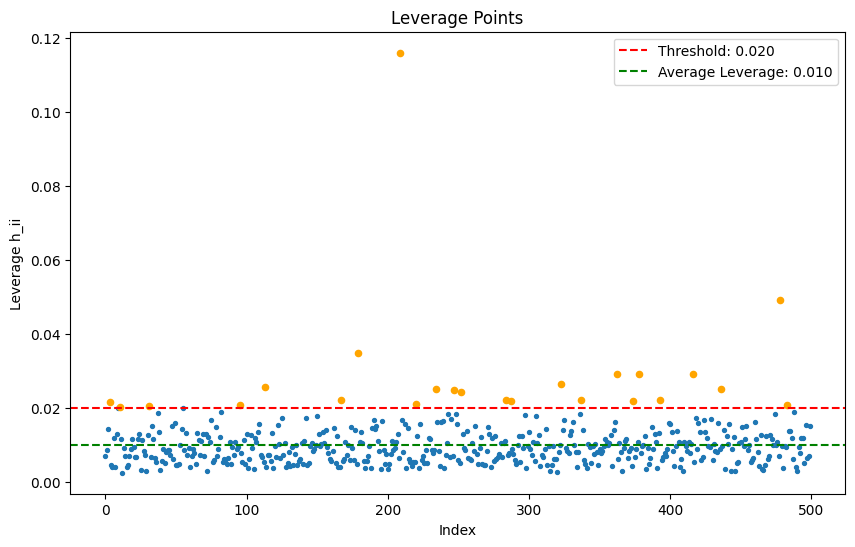

In [15]:
#Plotting leverage points
plt.figure(figsize=(10,6))
plt.scatter(summary['index'], summary['leverage'], s=8)
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.3f}')
plt.axhline(avg_leverage, color='g', linestyle='--', label=f'Average Leverage: {avg_leverage:.3f}')
hi_idx= summary.index[summary['leverage'] > threshold].tolist()
if len(hi_idx) > 0:
    plt.scatter(hi_idx, summary.loc[hi_idx, 'leverage'], color='orange', s=20)
plt.title('Leverage Points')
plt.xlabel('Index')
plt.ylabel('Leverage h_ii')
plt.legend()

In [16]:
# Leverage Points
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.api as sm



In [17]:
# Generate synthetic data
np.random.seed(420)

#Normal House
house_size= np.random.normal(2000, 400, 100)
house_price= 100 + 0.5*house_size + np.random.normal(0, 20000, 100)

#Add few mansions 
house_size= np.append(house_size, [5000, 6000, 7000])
house_price= np.append(house_price, [450000, 550000, 800000])

#Fit linear model 
X= sm.add_constant(house_size)
model= sm.OLS(house_price, X).fit()


In [18]:
# Printing model parameter
print(f'Model with mansions:\nIntercept: {model.params[0]:.2f}\nSlope: {model.params[1]:.2f}\n')

Model with mansions:
Intercept: -215377.10
Slope: 114.70



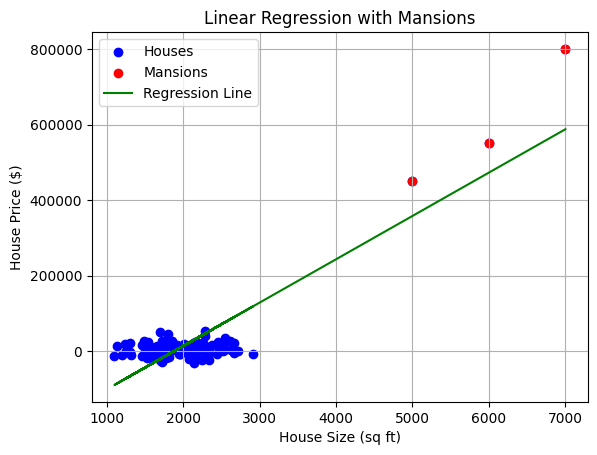

In [19]:
# Plot the data
plt.scatter(house_size, house_price, label='Houses', color='blue')
plt.scatter(house_size[-3:], house_price[-3:], label='Mansions', color='red')

#Plot the regression line
plt.plot(house_size, model.params[0] + model.params[1]*house_size, color='green', label='Regression Line')
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price ($)')
plt.title('Linear Regression with Mansions')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Get the leverage points
influence= model.get_influence()
leverage= influence.hat_matrix_diag
residuals= model.resid

#Threshold
n= len(house_size)
p= X.shape[1]
avg_lev= p/n
threshold= 2*avg_lev
print(f'Threshold: {threshold:}')

Threshold: 0.038834951456310676


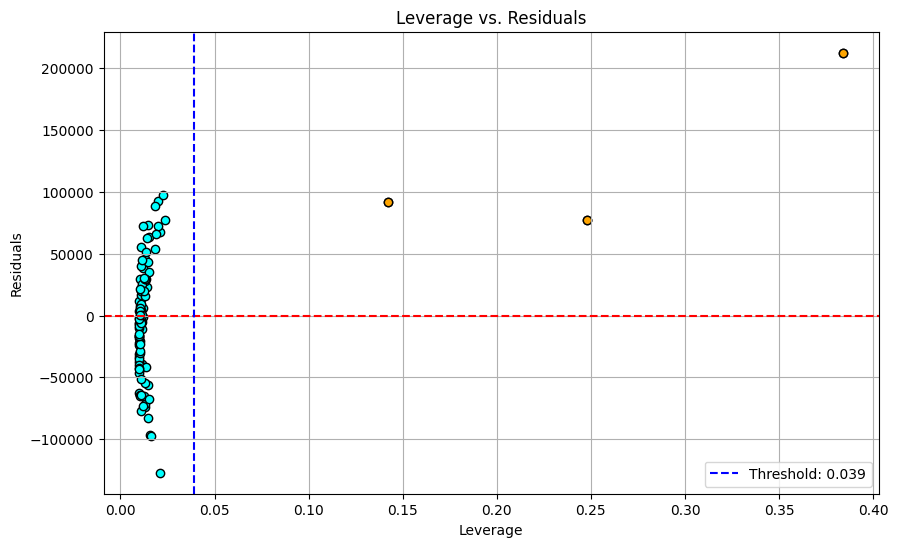

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(leverage, residuals, edgecolor='k', facecolor='cyan')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold: {threshold:.3f}')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Leverage vs. Residuals')
plt.legend()
plt.grid(True)

high_leverage_points= np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='orange', edgecolor='k', label='High Leverage Points')

plt.show()


In [22]:
print(f"High leverage points(index): {high_leverage_points}\nLeverage values: {leverage[high_leverage_points]}")

High leverage points(index): [100 101 102]
Leverage values: [0.1422605  0.2478525  0.38415841]


Exercise 1

Use the Boston Housing dataset, analyse it, and identify its leverage points. This dataset is available in the seaborn library.

In [23]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [24]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS",
    "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]
df = pd.DataFrame(data, columns=columns)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [25]:
X = df
y = target

In [26]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          6.72e-135
Time:                        18:14:39   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

In [27]:
# Get influence measures
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

# Threshold
n = X.shape[0]
p = X.shape[1]
avg_lev = p/n
threshold = 2 * avg_lev
print(threshold)

0.05138339920948617


In [28]:
# Intercept term
X_mat = np.hstack([np.ones((X.shape[0], 1)), X.values])

# Compute hat matrix
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

In [29]:
# Printing model parameter
print("Model with mansions: ")

print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions: 
Intercept: 36.46
Slope: -0.11


C:\Users\kakop\AppData\Local\Temp\ipykernel_18288\4029489841.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {model.params[0]:.2f}")
C:\Users\kakop\AppData\Local\Temp\ipykernel_18288\4029489841.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.2f}")


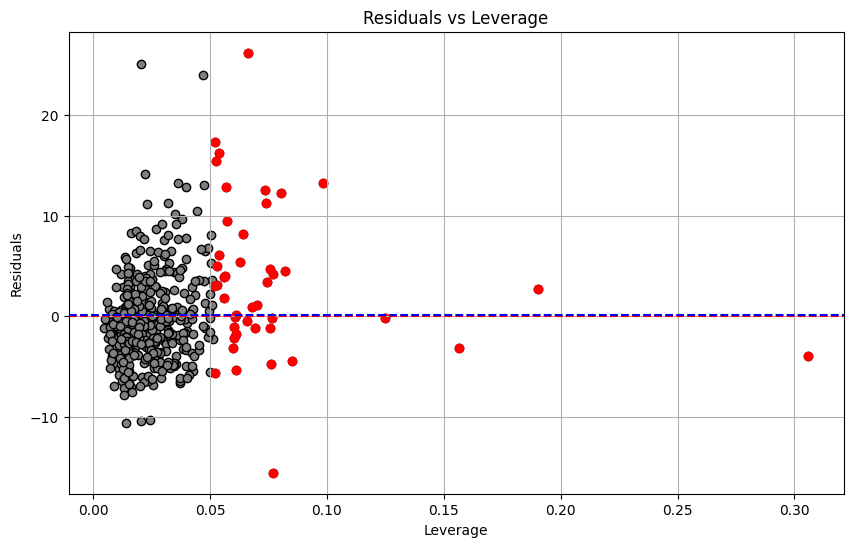

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(threshold, color='b', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)

high_leverage_points = np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='red', 
            label='High Leverage Points')
plt.show()

In [31]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage points: {leverage[high_leverage_points]}")

High leverage points (index): [  8 120 121 122 123 124 125 126 142 144 145 147 152 154 155 156 160 162
 163 209 214 253 283 353 354 355 364 365 367 368 369 370 380 405 410 412
 414 418 427 488 489 490 491 492]
Leverage points: [0.05287177 0.06098792 0.06013492 0.06061754 0.06795444 0.06092097
 0.06037207 0.06999688 0.06930322 0.0528894  0.05598942 0.05377772
 0.07613859 0.06130131 0.08527666 0.06589052 0.0519746  0.05741897
 0.06425294 0.05172053 0.07340449 0.05684161 0.06285775 0.07557389
 0.05607539 0.05626903 0.07672256 0.09851493 0.08043019 0.06633094
 0.05197883 0.05276017 0.30595949 0.15643251 0.12470699 0.05392577
 0.07387175 0.19010096 0.05961995 0.07420861 0.07570886 0.08206742
 0.07645812 0.07711251]


Exercise 2 

Use the diamonds dataset, analyze it, and identify its leverage points. This dataset is available in the seaborn library.

In [32]:
import seaborn as sns
df = sns.load_dataset('diamonds')
print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [33]:
X = df.drop(columns=['price']).select_dtypes(include=[np.number])
y = df['price']

In [34]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                 5.486e+04
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:14:46   Log-Likelihood:            -4.7090e+05
No. Observations:               53940   AIC:                         9.418e+05
Df Residuals:                   53933   BIC:                         9.419e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.085e+04    447.562     46.584      0.0

In [35]:
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

n = X.shape[0]
p = X.shape[1]
avg_lev = p / n
threshold = 2 * avg_lev

In [36]:
# Intercept term
X_mat = np.hstack([np.ones((X.shape[0], 1)), X.values])

# Compute hat matrix
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

print("Model with mansions: ")

print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions: 
Intercept: 20849.32
Slope: 10686.31


C:\Users\kakop\AppData\Local\Temp\ipykernel_18288\1755888953.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {model.params[0]:.2f}")
C:\Users\kakop\AppData\Local\Temp\ipykernel_18288\1755888953.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.2f}")


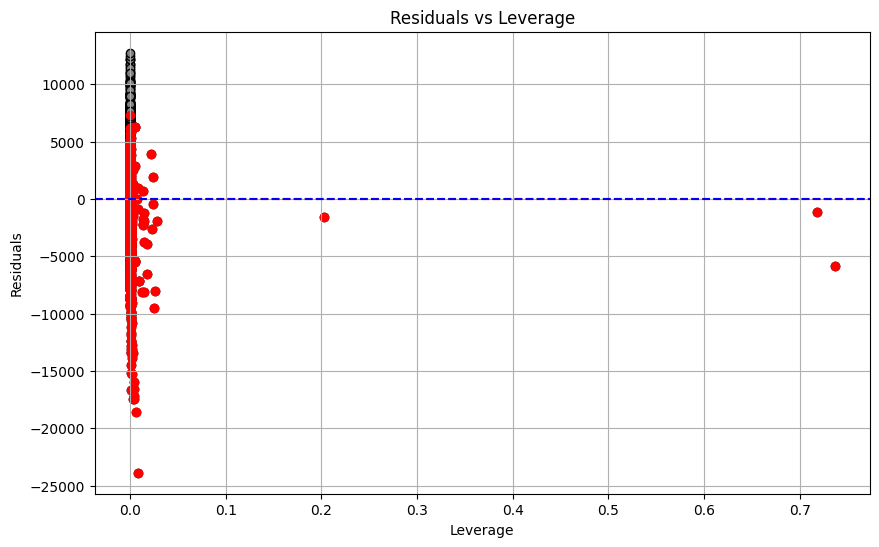

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(threshold, color='b', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)

high_leverage_points = np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='red', 
            label='High Leverage Points')
plt.show()

In [38]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage points: {leverage[high_leverage_points]}")

High leverage points (index): [    1     2     8 ... 53863 53890 53897]
Leverage points: [0.00022606 0.00050797 0.00034393 ... 0.00027142 0.0002524  0.00026746]
